In [1]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Settingan agar baris tidak dibatasi tampilannya saat print
pd.set_option('display.max_rows', None)

# Settingan agar kolom tidak dibatasi tampilannya saat print
pd.set_option('display.max_columns', None)

# Seetingan agar lebar kolom tidak terpotong
pd.set_option('display.width', None)

In [3]:
# Membuat tema global untuk visualisasi menjadi background putih dan memiliki grid
sns.set_theme(style="whitegrid")


In [4]:
# Upload data CSV hasil data cleansing query sql
file_path='../data/processed/rfm_base_data.csv'

In [5]:
# Membaca data hasil upload dengan pandas
df_rfm = pd.read_csv(file_path)

In [6]:
# Melihat struktur dataset
df_rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93358 entries, 0 to 93357
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  93358 non-null  object 
 1   recency_days        93358 non-null  int64  
 2   frequency           93358 non-null  int64  
 3   monetary            93358 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 2.8+ MB


In [7]:
# Cek tampilan 5 baris pertama data hasil upload dan pembacaan
df_rfm.head()

,customer_unique_id,recency_days,frequency,monetary
0,0a0a92112bd4c708ca5fde585afaa872,333,1,13440.0
1,da122df9eeddfedc1dc1f5349a1a690c,514,2,7388.0
2,763c8b1c9c68a0229c42c9fc6f662b93,45,1,7160.0
3,dc4802a71eae9be1dd28f5d788ceb526,562,1,6735.0
4,459bef486812aa25204be022145caa62,34,1,6729.0


In [8]:
# Menghitung RFM SCORES

# R_Score: Dibagi menjadi 4 kelompok (kuartil). Nilai recency terkecil mendapat skor 4.
df_rfm['R_Score'] = pd.qcut(df_rfm['recency_days'], q=4, labels=[4,3,2,1])

# M_Score: Dibagi menjadi 4 kelompok. Nilai monetary terbesar mendapat skor 4.
df_rfm['M_Score'] = pd.qcut(df_rfm['monetary'], q=4, labels=[1,2,3,4])

# Membuat function untuk di get F_Score 
# F_Score: Pengelompokan manual karena anomali data (mayoritas transaksi hanya 1 kali)
def f_scoring(x):
  if x == 1:
    return 1
  elif x == 2:
    return 2
  elif x == 3:
    return 3
  else:
    return 4
df_rfm['F_Score'] = df_rfm['frequency'].apply(f_scoring)

# Menggabungkan skor menjadi satu kode unik (misal: R=4, F=1, M=4 menjadi '414')
df_rfm['RFM_Segment_Code'] = df_rfm['R_Score'].astype(str) + df_rfm['F_Score'].astype(str) + df_rfm['M_Score'].astype(str)

# Membuat skor total untuk mempermudah pemeringkatan pelanggan (Skor maksimal = 12)
df_rfm['RFM_Total_Score'] = df_rfm['R_Score'].astype(int) + df_rfm['F_Score'].astype(int) + df_rfm['M_Score'].astype(int)

# Menampilkan hasil pengelompokan dengan kondisi RFM_Total_Score == 12
# df_rfm[df_rfm['RFM_Total_Score'] == 12][
# ['customer_unique_id','R_Score','F_Score','M_Score','RFM_Segment_Code','RFM_Total_Score']
# ].head(10)

# Menampilkan hasil pengelompokan tanpa kondisi
df_rfm[['customer_unique_id','R_Score','F_Score','M_Score','RFM_Segment_Code','RFM_Total_Score']].head(10)

,customer_unique_id,R_Score,F_Score,M_Score,RFM_Segment_Code,RFM_Total_Score
0,0a0a92112bd4c708ca5fde585afaa872,2,1,4,214,7
1,da122df9eeddfedc1dc1f5349a1a690c,1,2,4,124,7
2,763c8b1c9c68a0229c42c9fc6f662b93,4,1,4,414,9
3,dc4802a71eae9be1dd28f5d788ceb526,1,1,4,114,6
4,459bef486812aa25204be022145caa62,4,1,4,414,9
5,ff4159b92c40ebe40454e3e6a7c35ed6,1,1,4,114,6
6,4007669dec559734d6f53e029e360987,2,1,4,214,7
7,eebb5dda148d3893cdaf5b5ca3040ccb,1,1,4,114,6
8,48e1ac109decbb87765a3eade6854098,4,1,4,414,9
9,a229eba70ec1c2abef51f04987deb7a5,4,1,4,414,9


In [36]:
# PEMETAAN SEGMEN PELANGGAN (BUSINESS LOGIC)
def assign_segment(row):
  r = row['R_Score']
  f = row['F_Score']
  m = row['M_Score']

  # Logika Bisnis khusus karakteristik E-commerce Olist
  # Jika Frequency atau kedatangan lebih dari sama dengan 2
  if f >= 2:
    # Jika belanja lebih dari 1 kali, Mereka adalah pelanggan spesial
    if r >= 3:
      # Jika Recency/terakhir kunjungan lebih dekat dari waktu saat ini atau dari waktu terakhir report 
      return '1. Loyal Customers (Active)'
    else:
      # Jika Recency/terakhir kunjungan jauh dari waktu saat ini atau dari waktu terakhir report
      return '2. At Risk (Loyal but Inactive)'
  else:
  # Jika Frequency atau kedatangan kurang dari 2 (F=1), Pelanggan biasa
    if r >= 3:
      # Jika Recency/terakhir kunjungan lebih dekat dari waktu saat ini atau dari waktu terakhir report
      if m >= 3:
        # Jika Monetary/pembelian besar dan masuk kelompok poin 3
        return '3. New Customers (High Spender)'
      else:
        # Jika Monetary/pembelian rendah dan masuk kelompok poin 2 kebawah
        return '4. New Customers (Low Spender)'
    else:
    # Jika Recency/terakhir kunjungan jauh dari waktu saat ini atau dari waktu terakhir report
      if m >= 3:
      # Jika Monetary/pembelian besar dan masuk kelompok poin 3
        return '5. Lost Customers (High Spender)'
      else:
      # Jika Monetary/pembelian rendah dan masuk kelompok poin 2 kebawah
        return '6. Lost Customers (Low Spender)'

# Menerapkan fungsi segmentasi ke dalam DataFrame
df_rfm['Customer_Segment']=df_rfm.apply(assign_segment, axis=1)

# Menghitung jumlah pelanggan di masing - masing segmen
segment_counts = df_rfm['Customer_Segment'].value_counts().reset_index()
segment_counts.columns = ['Customer_Segment', 'Total_Customers']

# Menambahkan Kolom Presentase Total_Customers
# Mentotal keseluruhan pelanggan
total_all_customers = segment_counts['Total_Customers'].sum()

# Membuat kolom baru Precentage_(%) dan menghitung presentasenya
segment_counts['Percentage_(%)'] = round((segment_counts['Total_Customers']/total_all_customers) * 100,2)

# Menambahkan simbol % untuk memudahkan pembacaan 
segment_counts['Percentage_(%)'] = segment_counts['Percentage_(%)'].astype(str) + '%'

# Menampilkan hasil rekapitulasi segment dengan sorting Customer_Segment
segment_counts.sort_values('Customer_Segment', ascending=True).reset_index(drop=True)

# segment_counts

,Customer_Segment,Total_Customers,Percentage_(%)
0,1. Loyal Customers (Active),1549,1.66%
1,2. At Risk (Loyal but Inactive),1252,1.34%
2,3. New Customers (High Spender),22360,23.95%
3,4. New Customers (Low Spender),22938,24.57%
4,5. Lost Customers (High Spender),21976,23.54%
5,6. Lost Customers (Low Spender),23283,24.94%


C:\Users\satria.bagaskara\AppData\Local\Temp\ipykernel_9980\552679040.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


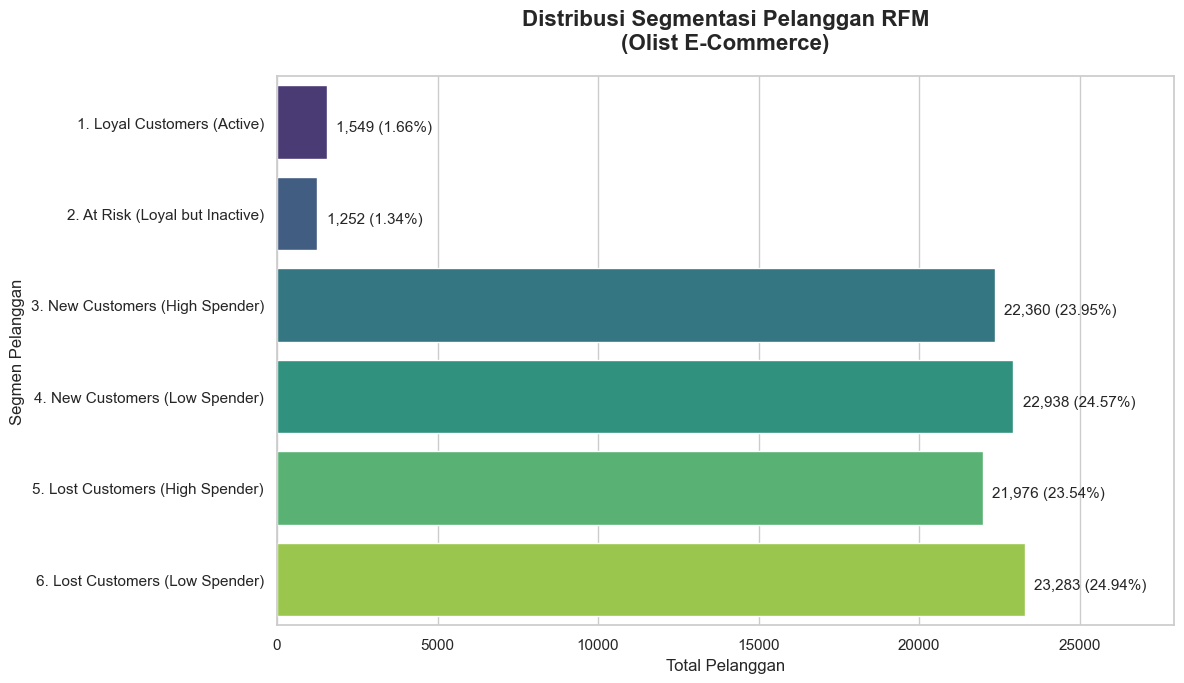

In [84]:
# =========================================================
# VISUALISASI SEGMEN PELANGGAN RFM
# =========================================================

# Mengurutkan data dan mereset index agar selaras saat di looping di grafik
df_plot = segment_counts.sort_values('Customer_Segment', ascending=True).reset_index(drop=True)

# Menentukan ukuran kanvas grafik
plt.figure(figsize=(12, 7))

# Membuat bar chart horisontal
ax = sns.barplot(
  x = 'Total_Customers',
  y = 'Customer_Segment',
  data=df_plot,
  palette='viridis'
  )

# Menambah judul dan label sumbu
plt.title('Distribusi Segmentasi Pelanggan RFM\n(Olist E-Commerce)', 
          fontsize=16,
          fontweight='bold',
          pad=20
          )
plt.xlabel('Total Pelanggan',fontsize=12)
plt.ylabel('Segmen Pelanggan',fontsize=12)

# Menambahkan angka aktual & presentase di ujung setiap batang
for i, p in enumerate(ax.patches):
  width = p.get_width()

  # Mengambil nilai teks persentase dari dataframe
  percentage_text = df_plot.loc[i, 'Percentage_(%)']

  # Menulis total presentase
  plt.text(width + 300, p.get_y() + p.get_height()/2. + 0.1,
           f'{int(width):,} ({percentage_text})',
            ha="left", fontsize=11)

# Melebarkan bingkai grafik
max_value = df_plot['Total_Customers'].max()
plt.xlim(0,max_value * 1.2)

# Merapihkan tata letak agar tidak terpotong
plt.tight_layout()

# Menyimpan grafik sebagai gambar PNG di Folder Proyek
plt.savefig('../data/processed/rfm_segmentation_chart.png', dpi=300)

# Menampilkan grafik di layar
plt.show()